In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, brier_score_loss,
    RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

In [ ]:
train        = pd.read_csv("train_v2.csv")
members      = pd.read_csv("members_v3.csv")
transactions = pd.read_csv("transactions_v2.csv")
user_logs    = pd.read_csv("user_logs_v2.csv")

print(f"Train shape:        {train.shape}")
print(f"Members shape:      {members.shape}")
print(f"Transactions shape: {transactions.shape}")
print(f"User logs shape:    {user_logs.shape}")

churn_rate = train["is_churn"].mean()
print(f"\nBase churn rate: {churn_rate:.2%}")

Train shape:        (970960, 2)
Members shape:      (6769473, 6)
Transactions shape: (1431009, 9)
User logs shape:    (18396362, 9)

Base churn rate: 8.99%



Churn rate: 8.99%


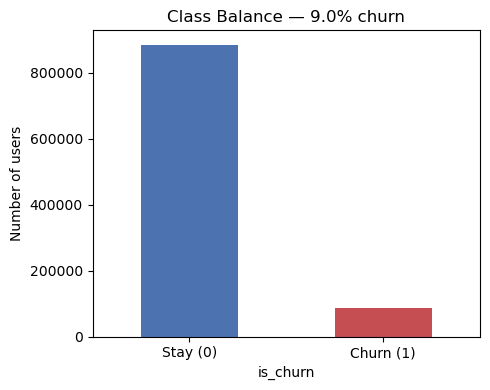

In [ ]:
# =============================================================================
# EDA
# =============================================================================

# --- Churn balance ---------------------------------------------------------
# How imbalanced is the target?
# If only ~9% of users churn, accuracy is a useless metric (predicting "nobody churns" would score 91%). 
# This tells us we'll need AUC and class weighting later.

churn_rate = train["is_churn"].mean()
print(f"\nChurn rate: {churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(5, 4))
train["is_churn"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Stay (0)", "Churn (1)"], rotation=0)
ax.set_title(f"Class Balance — {churn_rate:.1%} churn")
ax.set_ylabel("Number of users")
plt.tight_layout()
plt.show()

In [ ]:
# --- Merge a sample for exploration ---------------------------------------
# To explore relationships, join the label onto the raw tables.
# We aggregate transactions to one-row-per-user first so the join is clean.

txn_latest = (
    transactions
    .sort_values("transaction_date")
    .groupby("msno")
    .tail(1)
)

eda = train.merge(txn_latest, on="msno", how="left").merge(members, on="msno", how="left")
print(f"\nEDA frame: {eda.shape}")


EDA frame: (970960, 15)



Churn rate by auto-renew status:
is_auto_renew
0.0    0.305643
1.0    0.038274
Name: is_churn, dtype: float64


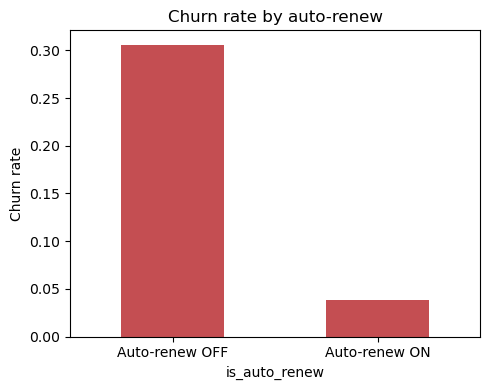

In [ ]:
# --- Auto-renew vs churn ---------------------------------------------------
# Hypothesis: users with auto-renew OFF are far more likely to churn — they've already taken the action needed to stop paying. 

print("\nChurn rate by auto-renew status:")
print(eda.groupby("is_auto_renew")["is_churn"].mean())

fig, ax = plt.subplots(figsize=(5, 4))
eda.groupby("is_auto_renew")["is_churn"].mean().plot(kind="bar", ax=ax, color="#C44E52")
ax.set_xticklabels(["Auto-renew OFF", "Auto-renew ON"], rotation=0)
ax.set_title("Churn rate by auto-renew")
ax.set_ylabel("Churn rate")
plt.tight_layout()
plt.show()

In [ ]:
# --- Listening behavior vs churn -------------------------------------------
# Engagement could be another big predictor. Are churners listening less before they go?
# Aggregate total listening seconds per user from the logs and compare.

logs_agg = user_logs.groupby("msno").agg(
    avg_secs   = ("total_secs", "mean"),
    active_days= ("date", "nunique"),
).reset_index()

eda2 = train.merge(logs_agg, on="msno", how="left")

print("\nMean listening seconds by churn status:")
print(eda2.groupby("is_churn")["avg_secs"].median())

print("\nMean active days by churn status:")
print(eda2.groupby("is_churn")["active_days"].median())


Mean listening seconds by churn status:
is_churn
0    4708.150000
1    4717.178173
Name: avg_secs, dtype: float64

Mean active days by churn status:
is_churn
0    19.0
1    16.0
Name: active_days, dtype: float64


In [ ]:
# =============================================================================
# FEATURE SELECTION & ENGINEERING
# =============================================================================

REFERENCE_DATE = pd.Timestamp("2017-03-31")

def build_member_features(df):
    df = df.copy()
    df["registration_init_time"] = pd.to_datetime(
        df["registration_init_time"].astype(str), format="%Y%m%d", errors="coerce"
    )
    df["account_age_days"] = (REFERENCE_DATE - df["registration_init_time"]).dt.days.clip(0, 15 * 365)
    df["age"] = df["bd"].where((df["bd"] >= 10) & (df["bd"] <= 70), np.nan)
    df["gender_enc"] = df["gender"].map({"female": 0, "male": 1}).fillna(0.5)
    return df[["msno", "age", "gender_enc", "registered_via", "account_age_days"]]
 
 
def build_transaction_features(df):
    df = df.copy()
    for col in ["transaction_date", "membership_expire_date"]:
        df[col] = pd.to_datetime(df[col].astype(str), format="%Y%m%d", errors="coerce")
    df["discount"] = df["plan_list_price"] - df["actual_amount_paid"]
 
    agg = df.groupby("msno").agg(
        n_transactions  = ("transaction_date", "count"),
        auto_renew_rate = ("is_auto_renew", "mean"),    # KEPT: leading intent signal
        mean_paid       = ("actual_amount_paid", "mean"),
        mean_discount   = ("discount", "mean"),
        last_txn_date   = ("transaction_date", "max"),
        # NOTE: ever_cancelled / is_cancel intentionally OMITTED (leakage)
    ).reset_index()
 
    agg["days_since_last_txn"] = (REFERENCE_DATE - agg["last_txn_date"]).dt.days.clip(0)
    agg.drop(columns=["last_txn_date"], inplace=True)
    return agg
 
 
def build_userlog_features(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
 
    agg = df.groupby("msno").agg(
        avg_secs_played  = ("total_secs", "mean"),
        avg_unique_songs = ("num_unq", "mean"),
        active_days      = ("date", "nunique"),
        total_plays      = ("num_100", "sum"),
        last_log_date    = ("date", "max"),
    ).reset_index()
 
    agg["days_since_last_log"] = (REFERENCE_DATE - agg["last_log_date"]).dt.days.clip(0)
    agg.drop(columns=["last_log_date"], inplace=True)
    return agg
 
 
members_feat      = build_member_features(members)
transactions_feat = build_transaction_features(transactions)
userlog_feat      = build_userlog_features(user_logs)
 
df = (
    train
    .merge(members_feat,      on="msno", how="left")
    .merge(transactions_feat, on="msno", how="left")
    .merge(userlog_feat,      on="msno", how="left")
)

feature_cols = [c for c in df.columns if c not in ("msno", "is_churn")]
print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")

print("\nCorrelation of each feature with churn:")
print(df[feature_cols + ["is_churn"]].corr()["is_churn"].drop("is_churn").sort_values(ascending=False))


Features (14): ['age', 'gender_enc', 'registered_via', 'account_age_days', 'n_transactions', 'auto_renew_rate', 'mean_paid', 'mean_discount', 'days_since_last_txn', 'avg_secs_played', 'avg_unique_songs', 'active_days', 'total_plays', 'days_since_last_log']

Correlation of each feature with churn:
mean_paid              0.429304
days_since_last_log    0.240268
days_since_last_txn    0.225801
n_transactions         0.149785
mean_discount          0.087948
avg_unique_songs       0.006064
gender_enc             0.003211
account_age_days       0.001895
avg_secs_played       -0.000723
total_plays           -0.021722
active_days           -0.065513
registered_via        -0.080642
age                   -0.095639
auto_renew_rate       -0.313766
Name: is_churn, dtype: float64


In [ ]:
# =============================================================================
# TRAIN / VALIDATION SPLIT
# =============================================================================
X = df[feature_cols]
y = df["is_churn"].astype(int)
 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, churn {y_train.mean():.2%}")
print(f"Val:   {X_val.shape}, churn {y_val.mean():.2%}")


Train: (776768, 14), churn 8.99%
Val:   (194192, 14), churn 8.99%


In [ ]:
# =============================================================================
# MODEL TRAINING
# =============================================================================
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"\nscale_pos_weight = {scale_pos_weight:.2f}")
 
model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
 
print("Training behavioral model...")
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
print(f"\nBest iteration: {model.best_iteration}")
print(f"Best val AUC:   {model.best_score:.4f}")


scale_pos_weight = 10.12
Training behavioral model...
[0]	validation_0-auc:0.92997
[50]	validation_0-auc:0.95981
[100]	validation_0-auc:0.96491
[150]	validation_0-auc:0.96777
[200]	validation_0-auc:0.96922
[250]	validation_0-auc:0.97002
[300]	validation_0-auc:0.97049
[350]	validation_0-auc:0.97079
[399]	validation_0-auc:0.97100

Best iteration: 399
Best val AUC:   0.9710



Validation AUC-ROC: 0.9710

Classification report (threshold = 0.5):
              precision    recall  f1-score   support

        Stay       0.99      0.93      0.96    176726
       Churn       0.56      0.89      0.68     17466

    accuracy                           0.93    194192
   macro avg       0.77      0.91      0.82    194192
weighted avg       0.95      0.93      0.93    194192

Confusion matrix:
               Pred Stay   Pred Churn
True Stay         164365        12361
True Churn          1952        15514


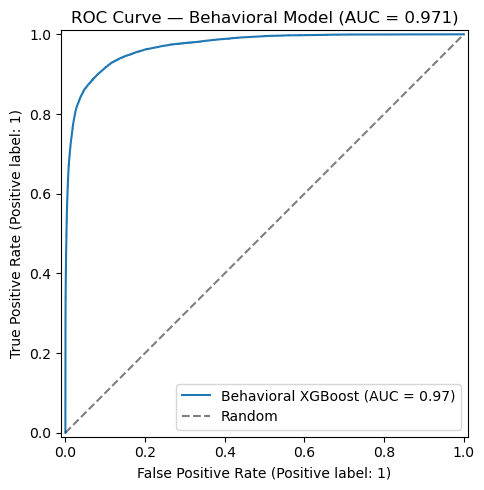

In [ ]:
# =============================================================================
# EVALUATION
# =============================================================================
y_prob = model.predict_proba(X_val)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_val, y_prob)
print(f"\nValidation AUC-ROC: {auc:.4f}")
print("\nClassification report (threshold = 0.5):")
print(classification_report(y_val, y_pred, target_names=["Stay", "Churn"]))

cm = confusion_matrix(y_val, y_pred)
print("Confusion matrix:")
print(f"               Pred Stay   Pred Churn")
print(f"True Stay      {cm[0,0]:>9}   {cm[0,1]:>10}")
print(f"True Churn     {cm[1,0]:>9}   {cm[1,1]:>10}")

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_val, y_prob, ax=ax, name="Behavioral XGBoost")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
ax.set_title(f"ROC Curve — Behavioral Model (AUC = {auc:.3f})")
ax.legend()
plt.tight_layout()
plt.show()